In [1]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt 


In [2]:
df=pd.read_csv("Rajshahi-Srimongals.csv")

# Basic Info. From Dataset

In [3]:
df.head(10)

,Region,Year,Month,Date,ST-10,ST-30,ST-50,Temperature
0,Srimongal,2001,1,1,21.75,22.20,22.10,18.0
1,Srimongal,2001,1,2,22.90,22.55,22.25,18.6
2,Srimongal,2001,1,3,22.50,22.60,22.40,19.4
3,Srimongal,2001,1,4,22.05,22.50,22.50,19.0
4,Srimongal,2001,1,5,20.40,21.70,22.20,16.4
5,Srimongal,2001,1,6,19.80,20.70,21.60,14.0
6,Srimongal,2001,1,7,18.90,20.10,21.20,12.7
7,Srimongal,2001,1,8,18.90,20.05,20.85,12.8
8,Srimongal,2001,1,9,18.70,19.90,20.30,13.5
9,Srimongal,2001,1,10,19.50,20.30,20.60,15.2


In [4]:
df.shape

(16070, 8)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16070 entries, 0 to 16069
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Region       16070 non-null  object 
 1   Year         16070 non-null  int64  
 2   Month        16070 non-null  int64  
 3   Date         16070 non-null  int64  
 4   ST-10        16070 non-null  float64
 5   ST-30        16070 non-null  float64
 6   ST-50        16070 non-null  float64
 7   Temperature  16070 non-null  float64
dtypes: float64(4), int64(3), object(1)
memory usage: 1004.5+ KB


In [6]:
df.isnull().sum()

Region         0
Year           0
Month          0
Date           0
ST-10          0
ST-30          0
ST-50          0
Temperature    0
dtype: int64

In [7]:
df.describe()

,Year,Month,Date,ST-10,ST-30,ST-50,Temperature
count,16070.000000,16070.000000,16070.000000,16070.000000,16070.000000,16070.000000,16070.000000
mean,2011.500311,6.523522,15.728811,27.192778,27.485732,27.181801,25.014396
std,6.344094,3.448821,8.800017,4.770993,4.401427,4.058129,4.854033
min,2001.000000,1.000000,1.000000,14.300000,15.600000,15.550000,8.500000
25%,2006.000000,4.000000,8.000000,23.200000,23.900000,23.800000,21.200000
50%,2012.000000,7.000000,16.000000,28.800000,29.100000,28.565000,26.600000
75%,2017.000000,10.000000,23.000000,31.000000,31.060000,30.500000,28.800000
max,2022.000000,12.000000,31.000000,38.000000,36.800000,36.300000,34.800000


In [8]:
df.duplicated().sum()

0

In [9]:
df.groupby('Region')[['Temperature','ST-10','ST-30','ST-50']].max()

,Temperature,ST-10,ST-30,ST-50
Region,,,,
Rajshahi,34.8,38.0,36.80,36.30
Srimongal,32.4,34.4,33.35,34.51


In [10]:
df.groupby('Region')['Temperature'].min()

Region
Rajshahi     10.0
Srimongal     8.5
Name: Temperature, dtype: float64

In [11]:
df.columns

Index(['Region', 'Year', 'Month', 'Date', 'ST-10', 'ST-30', 'ST-50',
       'Temperature'],
      dtype='object')

In [12]:
x=df[['Region', 'Temperature', 'ST-10', 'ST-30', 'ST-50']]

In [13]:
x.sample()

,Region,Temperature,ST-10,ST-30,ST-50
3101,Srimongal,27.6,29.3,30.7,30.3


In [14]:
x.groupby('Region').corr()['Temperature']

Region                
Rajshahi   Temperature    1.000000
           ST-10          0.970857
           ST-30          0.957843
           ST-50          0.941232
Srimongal  Temperature    1.000000
           ST-10          0.955004
           ST-30          0.960132
           ST-50          0.942064
Name: Temperature, dtype: float64

# Preprocessing

In [15]:
df.dtypes

Region          object
Year             int64
Month            int64
Date             int64
ST-10          float64
ST-30          float64
ST-50          float64
Temperature    float64
dtype: object

In [16]:
df['Years'] = pd.to_datetime(df['Year'], format='%Y')

In [17]:
df['Years'].value_counts()

Years
2012-01-01    732
2004-01-01    732
2020-01-01    732
2008-01-01    732
2016-01-01    732
2013-01-01    730
2021-01-01    730
2019-01-01    730
2018-01-01    730
2017-01-01    730
2015-01-01    730
2014-01-01    730
2001-01-01    730
2002-01-01    730
2011-01-01    730
2010-01-01    730
2009-01-01    730
2007-01-01    730
2006-01-01    730
2005-01-01    730
2003-01-01    730
2022-01-01    730
Name: count, dtype: int64

In [18]:
df.sample()

,Region,Year,Month,Date,ST-10,ST-30,ST-50,Temperature,Years
15967,Rajshahi,2022,9,20,31.5,31.6,31.15,30.6,2022-01-01


# EDA

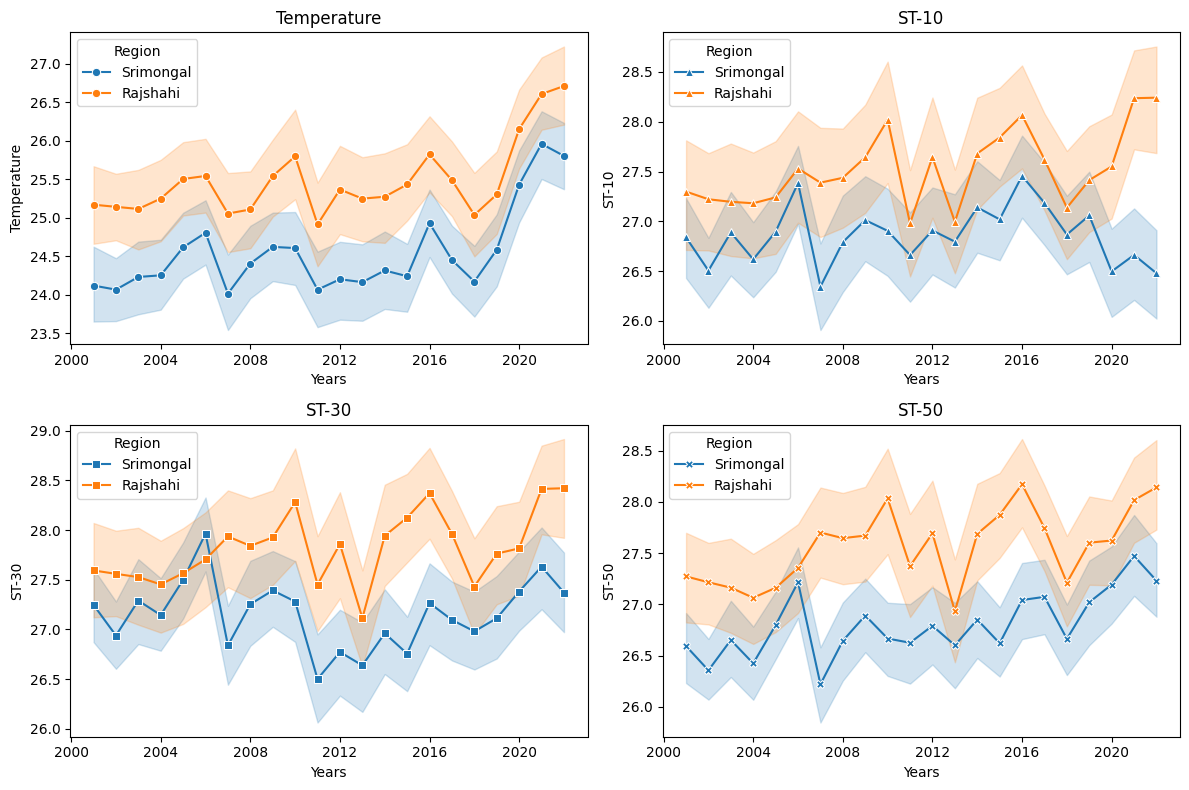

In [19]:


plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
sns.lineplot(x='Years', y='Temperature', hue='Region', marker='o', data=df)
plt.title("Temperature")

plt.subplot(2, 2, 2)
sns.lineplot(x='Years', y='ST-10', hue='Region', marker='^', data=df)
plt.title("ST-10")

plt.subplot(2, 2, 3)
sns.lineplot(x='Years', y='ST-30', hue='Region', marker='s', data=df)
plt.title("ST-30")

plt.subplot(2, 2, 4)
sns.lineplot(x='Years', y='ST-50', hue='Region', marker='X', data=df)
plt.title("ST-50")


plt.tight_layout()
plt.show()


<Axes: xlabel='ST-50', ylabel='Temperature'>

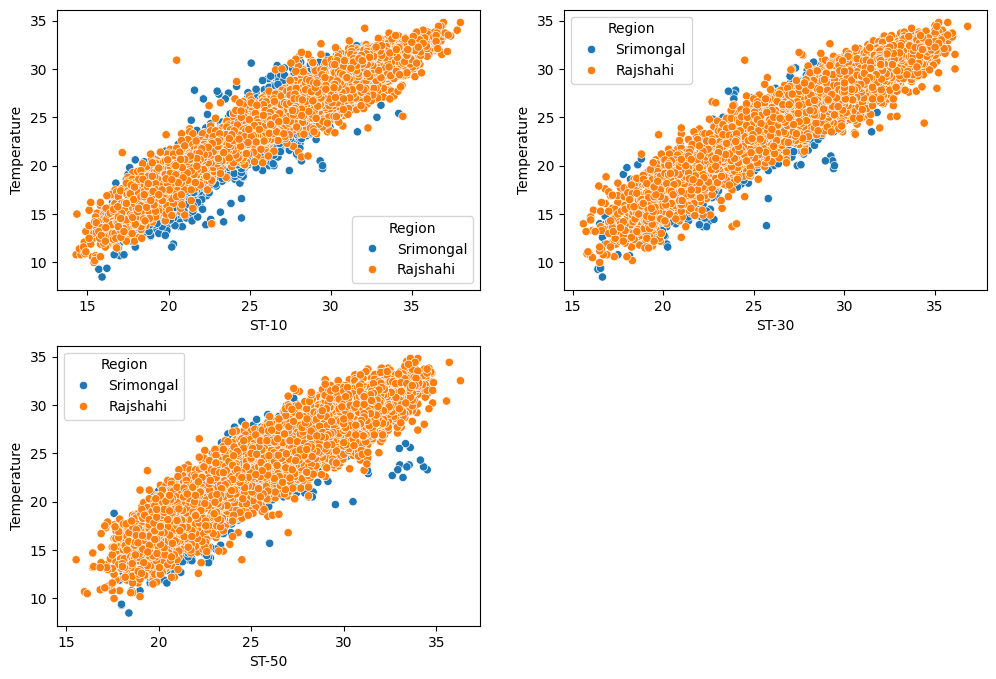

In [20]:
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
sns.scatterplot(x='ST-10',y='Temperature',hue='Region',data=df)

plt.subplot(2, 2, 2)
sns.scatterplot(x='ST-30',y='Temperature',hue='Region',data=df)

plt.subplot(2, 2, 3)
sns.scatterplot(x='ST-50',y='Temperature',hue='Region',data=df)


<Axes: xlabel='Region', ylabel='ST-50'>

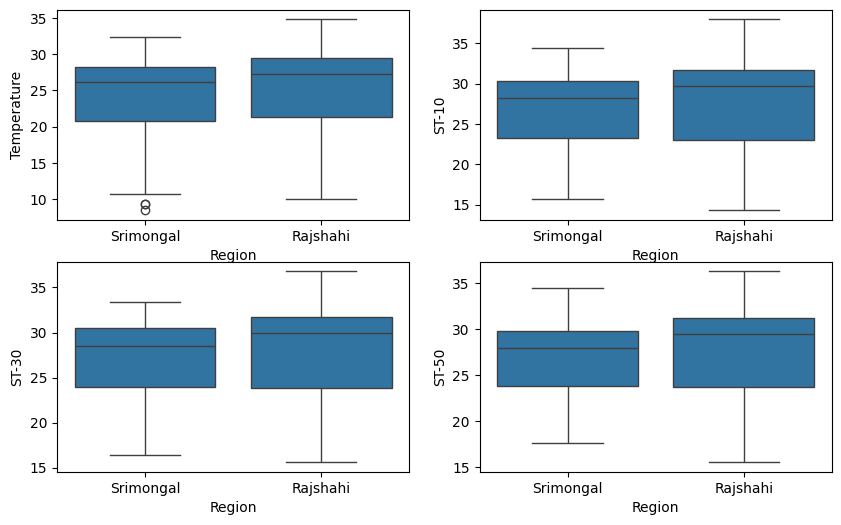

In [21]:
plt.figure(figsize=(10,6))

plt.subplot(2,2,1)
sns.boxplot(x='Region',y='Temperature',data=df)

plt.subplot(2,2,2)
sns.boxplot(x='Region',y='ST-10',data=df)

plt.subplot(2,2,3)
sns.boxplot(x='Region',y='ST-30',data=df)

plt.subplot(2,2,4)
sns.boxplot(x='Region',y='ST-50',data=df)

<Axes: >

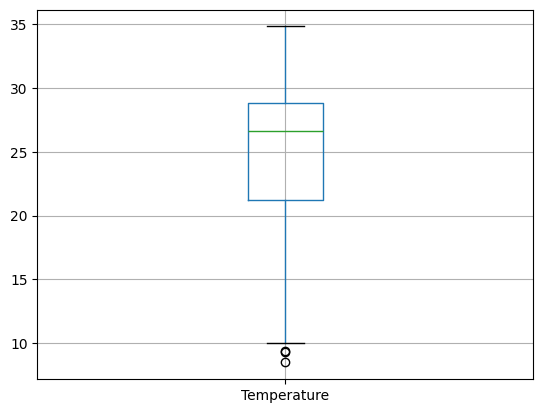

In [22]:
df.boxplot('Temperature')

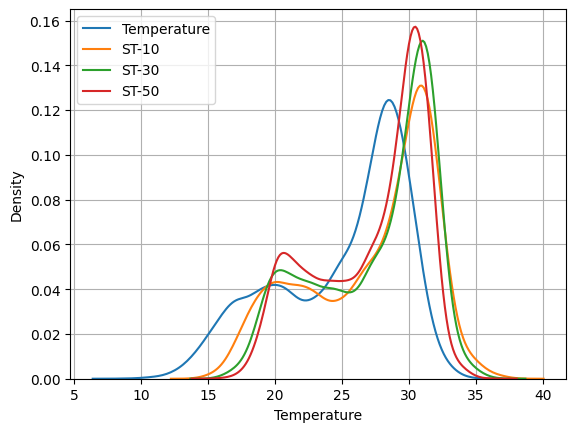

In [23]:
sns.kdeplot(df['Temperature'], label='Temperature', fill=False)
sns.kdeplot(df['ST-10'], label='ST-10', fill=False)
sns.kdeplot(df['ST-30'], label='ST-30', fill=False)
sns.kdeplot(df['ST-50'], label='ST-50', fill=False)
plt.grid()
plt.legend()

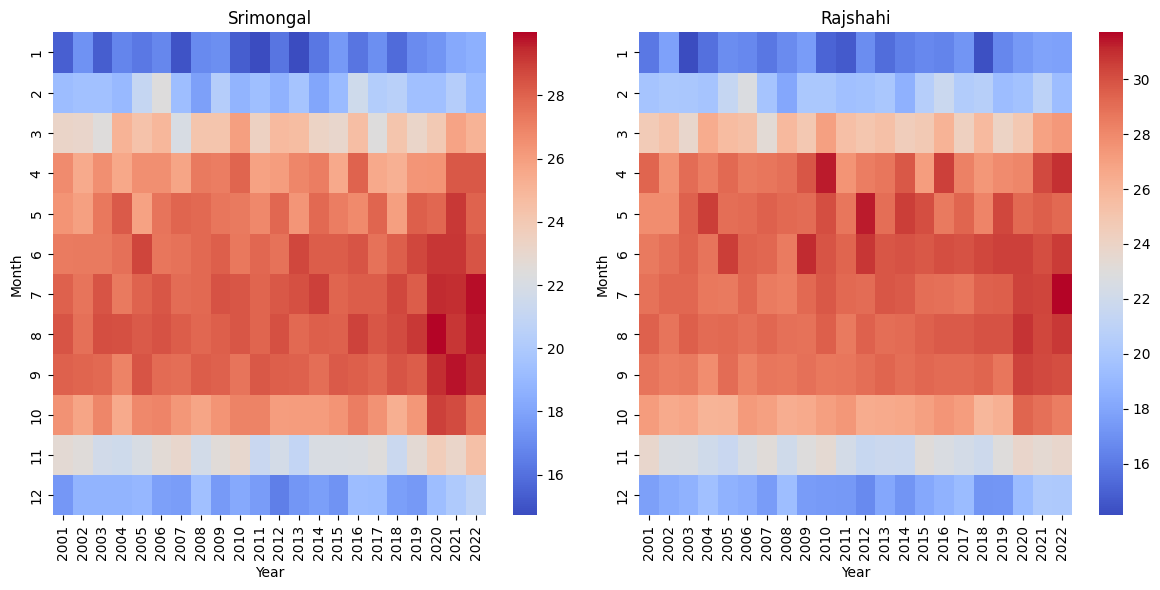

In [24]:

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.heatmap(df[df['Region']=='Srimongal'].pivot_table(values='Temperature', index='Month', columns='Year'), cmap='coolwarm')
plt.title('Srimongal')

plt.subplot(1, 2, 2)
sns.heatmap(df[df['Region']=='Rajshahi'].pivot_table(values='Temperature', index='Month', columns='Year'), cmap='coolwarm')
plt.title('Rajshahi')

plt.tight_layout()



# Model Selection

In [25]:
dff=df.copy()

In [26]:


data_raj=dff[dff['Region']=='Rajshahi']
data_sri=dff[dff['Region']=='Srimongal']


In [27]:
df_raj=data_raj[['Temperature', 'ST-10', 'ST-30', 'ST-50']]
df_sri=data_sri[['Temperature', 'ST-10', 'ST-30', 'ST-50']]

In [28]:
df_sri.sample()

,Temperature,ST-10,ST-30,ST-50
63,20.0,21.85,23.5,23.25


# Rajshahi Linear Regression

In [29]:
import math 



n=len(df_raj)

train_end=math.floor(n*0.80)
val_end=math.floor(n*0.90)

train_raj=df_raj.iloc[:train_end]
val_raj=df_raj.iloc[train_end:val_end]
test_raj=df_raj.iloc[val_end:]

In [30]:
X_train_raj=train_raj[['Temperature']]
y_train_raj=train_raj[['ST-10']]

X_val_raj=val_raj[['Temperature']]
y_val_raj=val_raj[['ST-10']]

X_test_raj=test_raj[['Temperature']]
y_test_raj=test_raj[['ST-10']]

In [31]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error


In [76]:
lr_raj=LinearRegression()
lr_raj.fit(X_train_raj,y_train_raj)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [78]:
y_raj_pred=lr_raj.predict(X_val_raj)

In [79]:
mae_raj=mean_absolute_error(y_val_raj,y_raj_pred)
mae_raj

0.9681153531571279

In [80]:
mse_raj=mean_squared_error(y_val_raj,y_raj_pred)
mse_raj

1.777503413720105

In [81]:
r2_raj=r2_score(y_val_raj,y_raj_pred)
r2_raj

0.9326248540435036

In [83]:
m_raj=lr_raj.coef_[0][0]
m_raj

1.017269702755961

In [82]:
c_raj=lr_raj.intercept_[0]
c_raj

1.691688205533037

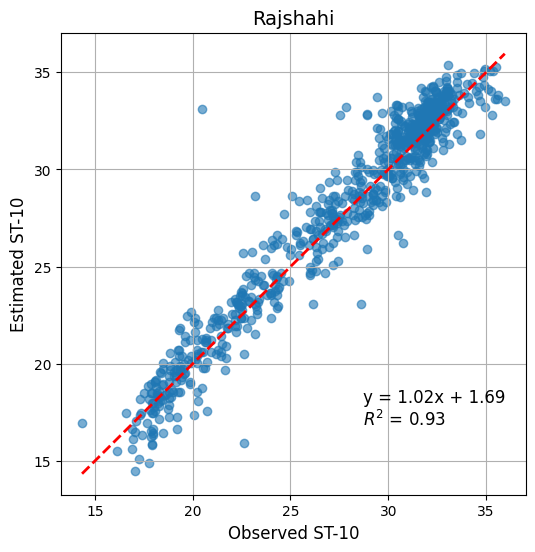

In [84]:


plt.figure(figsize=(6,6))
plt.scatter(y_val_raj, y_raj_pred, alpha=0.6)
plt.plot([y_val_raj.min(), y_val_raj.max()],
         [y_val_raj.min(), y_val_raj.max()],
         'r--', lw=2)

plt.text(0.65, 0.2, f'y = {m_raj:.2f}x + {c_raj:.2f}', transform=plt.gca().transAxes, fontsize=12)
plt.text(0.65, 0.15, f'$R^2$ = {r2_raj:.2f}', transform=plt.gca().transAxes, fontsize=12)

plt.xlabel('Observed ST-10', fontsize=12)
plt.ylabel('Estimated ST-10', fontsize=12)
plt.title('Rajshahi', fontsize=14)
plt.grid(True)
plt.show()


# Srimongal Linear Regression 

In [85]:
import math

m = len(df_sri)

train_end_sri = math.floor(m * 0.80)
val_end_sri = math.floor(m * 0.90)

train_sri = df_sri.iloc[:train_end_sri]
val_sri = df_sri.iloc[train_end_sri:val_end_sri]
test_sri = df_sri.iloc[val_end_sri:]


In [86]:
test_sri.shape

(804, 4)

In [87]:
X_train_sri = train_sri[['Temperature']]
y_train_sri = train_sri[['ST-10']]

X_val_sri = val_sri[['Temperature']]
y_val_sri = val_sri[['ST-10']]

X_test_sri = test_sri[['Temperature']]
y_test_sri = test_sri[['ST-10']]


In [88]:
Q1 = X_train_sri['Temperature'].quantile(0.25)
Q3 = X_train_sri['Temperature'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
X_train_sri['Temperature'] = X_train_sri['Temperature'].clip(lower=lower_bound, upper=upper_bound)


C:\Users\HP Laptop 15\AppData\Local\Temp\ipykernel_6128\970763780.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train_sri['Temperature'] = X_train_sri['Temperature'].clip(lower=lower_bound, upper=upper_bound)


<Axes: >

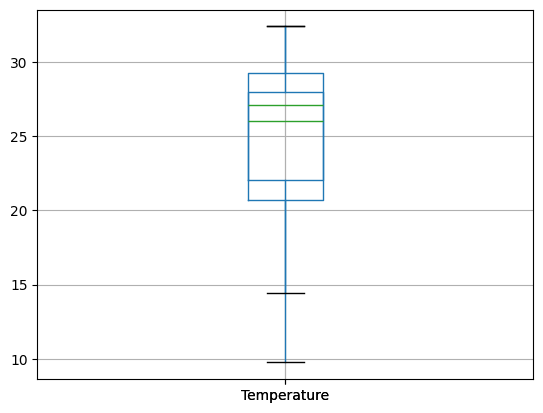

In [89]:
X_train_sri.boxplot('Temperature')
X_test_sri.boxplot('Temperature')

In [90]:
X_train_sri.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6428 entries, 0 to 6427
Data columns (total 1 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Temperature  6428 non-null   float64
dtypes: float64(1)
memory usage: 100.4 KB


In [91]:
lr_sri = LinearRegression()
lr_sri.fit(X_train_sri, y_train_sri)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [92]:
y_sri_pred=lm_sri.predict(X_val_sri)
mae_sri=mean_absolute_error(y_val_sri,y_sri_pred)
mse_sri=mean_squared_error(y_val_sri,y_sri_pred)
r2_sri=r2_score(y_val_sri,y_sri_pred)

In [93]:
print(mae_sri,mse_sri,r2_sri)

0.9076358309097926 1.4785994639368745 0.9163023142479992


In [94]:
m_sri=lr_sri.coef_[0][0]
m_sri

0.8798162027533577

In [95]:
c_sri=lr_sri.intercept_[0]
c_sri

5.481274887257179

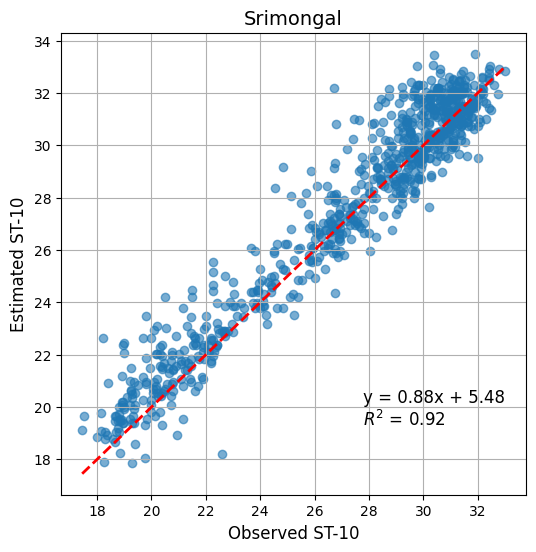

In [97]:

import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_val_sri, y_sri_pred, alpha=0.6)
plt.plot([y_val_sri.min(), y_val_sri.max()],
         [y_val_sri.min(), y_val_sri.max()],
         'r--', lw=2)

plt.text(0.65, 0.2, f'y = {m_sri:.2f}x + {c_sri:.2f}', transform=plt.gca().transAxes, fontsize=12)
plt.text(0.65, 0.15, f'$R^2$ = {r2_sri:.2f}', transform=plt.gca().transAxes, fontsize=12)

plt.xlabel('Observed ST-10', fontsize=12)
plt.ylabel('Estimated ST-10', fontsize=12)
plt.title('Srimongal', fontsize=14)
plt.grid(True)
plt.show()
